In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv(r"C:\Users\jmadh\Downloads\archive (1)\Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [4]:
df.isnull().sum()


price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [5]:
def remove_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]

df = remove_outliers('price')
df = remove_outliers('area')


In [9]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
15,9100000,6000,4,1,2,2,True,False,True,False,False,False,True,False
16,9100000,6600,4,2,2,1,True,True,True,False,True,True,False,True
17,8960000,8500,3,2,4,2,True,False,False,False,True,False,False,False
18,8890000,4600,3,2,2,2,True,True,False,False,True,False,False,False
19,8855000,6420,3,2,2,1,True,False,False,False,True,True,True,False


In [11]:
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
               'airconditioning', 'prefarea']

for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})


In [13]:
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)


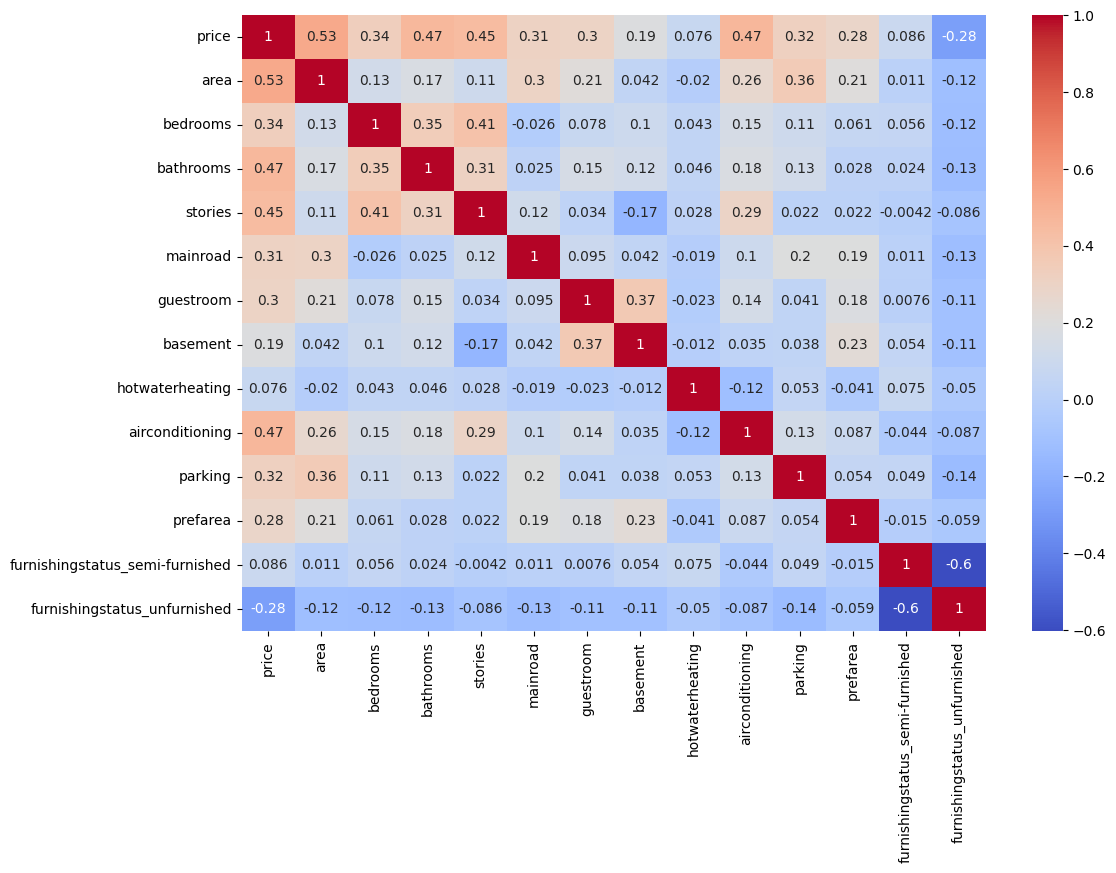

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True, cmap="coolwarm")
plt.show()


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ['area', 'bathrooms', 'stories', 'parking']

df[num_cols] = scaler.fit_transform(df[num_cols])


MULTIPLE LINEAR REGRESSION

In [17]:
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [19]:
lr = LinearRegression()
lr.fit(X_train, y_train)


LinearRegression()

In [20]:
y_pred = lr.predict(X_test)


In [21]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)


MAE: 734127.113119481
MSE: 954173744480.8965
RMSE: 976818.1737052687
R²: 0.6747673447811053


In [22]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
})
print(coef_df)


                            Feature    Coefficient
0                              area     246.272416
1                          bedrooms   99674.796239
2                         bathrooms  700075.712694
3                           stories  459516.904052
4                           parking  214359.721753
5                      mainroad_yes  389351.463480
6                     guestroom_yes  417119.933267
7                      basement_yes  309972.449583
8               hotwaterheating_yes  694272.523803
9               airconditioning_yes  867780.084698
10                     prefarea_yes  513811.014778
11  furnishingstatus_semi-furnished   -2498.335812
12     furnishingstatus_unfurnished -271269.983843


LINEAR REGRESSION

In [23]:
X2 = df[['area']]
y2 = df['price']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42)

lr2 = LinearRegression()
lr2.fit(X_train2, y_train2)

y_pred2 = lr2.predict(X_test2)


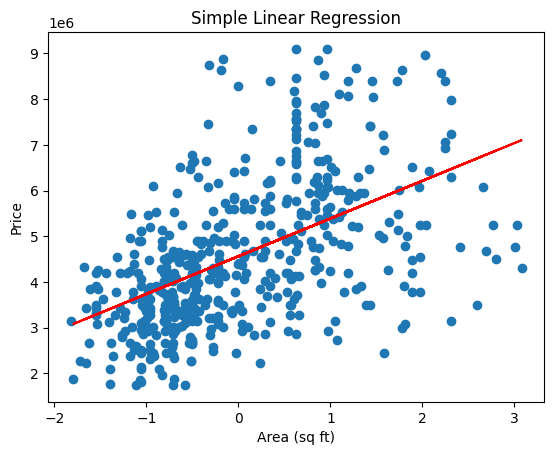

In [24]:
plt.scatter(X2, y2)
plt.plot(X_test2, y_pred2, color='red')
plt.xlabel("Area (sq ft)")
plt.ylabel("Price")
plt.title("Simple Linear Regression")
plt.show()


In [25]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)


MAE: 734127.113119481
MSE: 954173744480.8965
RMSE: 976818.1737052687
R² Score: 0.6747673447811053


In [26]:
print("Slope / Coefficient:", lr.coef_[0])
print("Intercept:", lr.intercept_)



Slope / Coefficient: 246.2724162320633
Intercept: 388000.350617995
